# Análise das vendas de supermercado

Aqui apresento as oito perguntas da atividade e os resultados da análise. Usei a base tratada, com os valores na unidade monetária original.

Este notebook é gerado pelo `03_estatistica.py`. Os resultados nos textos e os gráficos correspondem à execução desse script. As células de código podem ser executadas para conferir os cálculos.

Para atualizar todo o relatório, execute o script novamente. Isso substitui as alterações feitas diretamente no notebook.

## Leitura da base tratada

Primeiro, abro o CSV salvo na etapa de tratamento.

In [1]:
from pathlib import Path
import pandas as pd

# Localiza o projeto, tanto pela pasta principal quanto por resultados.
raiz = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'data/processed/vendas_tratadas.csv').exists())
df = pd.read_csv(raiz / 'data/processed/vendas_tratadas.csv')
df['data_venda'] = pd.to_datetime(df['data_venda'])
dias = {'Monday': 'Segunda-feira', 'Tuesday': 'Terça-feira', 'Wednesday': 'Quarta-feira', 'Thursday': 'Quinta-feira', 'Friday': 'Sexta-feira', 'Saturday': 'Sábado', 'Sunday': 'Domingo'}
df['dia_semana'] = df['data_venda'].dt.day_name().map(dias)
df.head()

,id_venda,filial,cidade,tipo_cliente,genero,linha_produto,preco_unitario,quantidade,imposto,valor_total,data_venda,hora_venda,forma_pagamento,custo_mercadoria,margem_percentual,receita_bruta,avaliacao,dia_semana,mes,periodo_dia
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.14,548.97,2019-01-05,13:08:00,Ewallet,522.83,4.76,26.14,9.1,Sábado,1,Tarde
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.82,80.22,2019-03-08,10:29:00,Cash,76.40,4.76,3.82,9.6,Sexta-feira,3,Manhã
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.22,340.53,2019-03-03,13:23:00,Credit card,324.31,4.76,16.22,7.4,Domingo,3,Tarde
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.29,489.05,2019-01-27,20:33:00,Ewallet,465.76,4.76,23.29,8.4,Domingo,1,Noite
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.21,634.38,2019-02-08,10:37:00,Ewallet,604.17,4.76,30.21,5.3,Sexta-feira,2,Manhã


## 1. Qual filial apresentou o maior faturamento?

Somei o valor das vendas de cada filial para comparar o faturamento.

In [2]:
df.groupby('filial')['valor_total'].sum().sort_values(ascending=False)

filial
Giza     110568.86
Alex     106200.57
Cairo    106198.00
Name: valor_total, dtype: float64

**Resultado:** Filial com maior faturamento: Giza (110.568,86)

## 2. Qual filial realizou a maior quantidade de vendas?

Contei os registros de venda de cada filial, sem somar as unidades vendidas.

In [3]:
df.groupby('filial')['id_venda'].count().sort_values(ascending=False)

filial
Alex     340
Cairo    332
Giza     328
Name: id_venda, dtype: int64

**Resultado:** Filial com mais vendas: Alex (340 vendas)

## 3. Qual linha de produto apresentou o maior faturamento?

Agrupei as vendas por linha de produto e somei os valores.

In [4]:
df.groupby('linha_produto')['valor_total'].sum().sort_values(ascending=False)

linha_produto
Food and beverages        56144.96
Sports and travel         55123.00
Electronic accessories    54337.64
Fashion accessories       54306.03
Home and lifestyle        53861.96
Health and beauty         49193.84
Name: valor_total, dtype: float64

**Resultado:** Linha com maior faturamento: Food and beverages (56.144,96)

## 4. Qual linha de produto recebeu a melhor avaliação média?

Calculei a média das avaliações de cada linha de produto.

In [5]:
df.groupby('linha_produto')['avaliacao'].mean().sort_values(ascending=False)

linha_produto
Food and beverages        7.113218
Fashion accessories       7.029213
Health and beauty         7.003289
Electronic accessories    6.924706
Sports and travel         6.916265
Home and lifestyle        6.837500
Name: avaliacao, dtype: float64

**Resultado:** Linha com melhor avaliação média: Food and beverages (nota média 7,11)

## 5. Qual foi a forma de pagamento mais utilizada?

Contei quantas vendas foram realizadas com cada forma de pagamento.

In [6]:
df['forma_pagamento'].value_counts()

forma_pagamento
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64

**Resultado:** Pagamento mais utilizado: Ewallet (345 vendas)

## 6. Qual foi o valor médio das vendas?

Calculei a média do valor total das vendas.

In [7]:
round(df['valor_total'].mean(), 2)

np.float64(322.97)

**Resultado:** Valor médio das vendas: 322,97

## 7. Qual foi a maior venda registrada?

Localizei a venda com o maior valor e mostrei suas informações.

In [8]:
df.loc[df['valor_total'].idxmax(),
       ['id_venda', 'filial', 'linha_produto', 'valor_total']]

id_venda                 860-79-0874
filial                          Giza
linha_produto    Fashion accessories
valor_total                  1042.65
Name: 350, dtype: object

**Resultado:** Maior venda: 1.042,65 (id=860-79-0874, filial=Giza, linha=Fashion accessories)

## 8. Em qual dia da semana ocorreu a maior quantidade de vendas?

Identifiquei o dia da semana de cada venda e contei os registros.

In [9]:
df['dia_semana'].value_counts()

dia_semana
Sábado           164
Terça-feira      158
Quarta-feira     143
Sexta-feira      139
Quinta-feira     138
Domingo          133
Segunda-feira    125
Name: count, dtype: int64

**Resultado:** Dia com mais vendas: Sábado (164 vendas)

## Estatística descritiva

Conferi a quantidade de valores, a média, o desvio padrão, o mínimo, os quartis e o máximo das colunas abaixo.

```text
       preco_unitario  quantidade  valor_total  custo_mercadoria  avaliacao
count         1000.00     1000.00      1000.00           1000.00    1000.00
mean            55.67        5.51       322.97            307.59       6.97
std             26.49        2.92       245.89            234.18       1.72
min             10.08        1.00        10.68             10.17       4.00
25%             32.88        3.00       124.42            118.50       5.50
50%             55.23        5.00       253.85            241.76       7.00
75%             77.94        8.00       471.35            448.90       8.50
max             99.96       10.00      1042.65            993.00      10.00
```

In [10]:
df[['preco_unitario', 'quantidade', 'valor_total', 'custo_mercadoria', 'avaliacao']].describe().round(2)

,preco_unitario,quantidade,valor_total,custo_mercadoria,avaliacao
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,55.67,5.51,322.97,307.59,6.97
std,26.49,2.92,245.89,234.18,1.72
min,10.08,1.00,10.68,10.17,4.00
25%,32.88,3.00,124.42,118.50,5.50
50%,55.23,5.00,253.85,241.76,7.00
75%,77.94,8.00,471.35,448.90,8.50
max,99.96,10.00,1042.65,993.00,10.00


## Gráficos

Os gráficos abaixo foram gerados na mesma execução da análise.

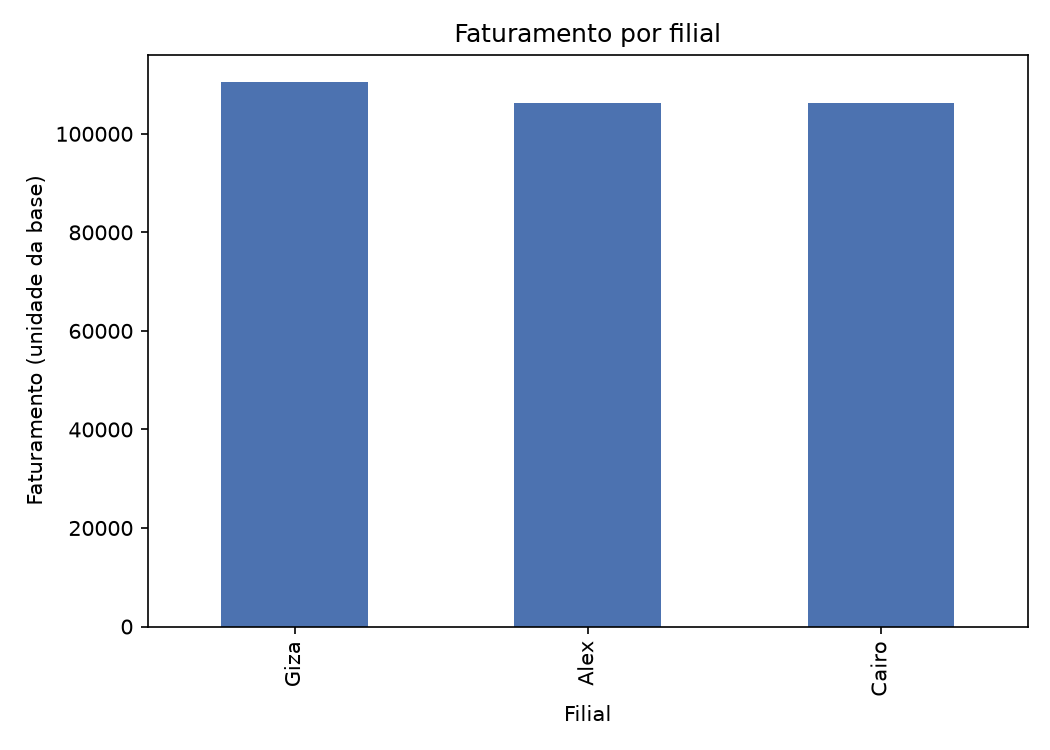

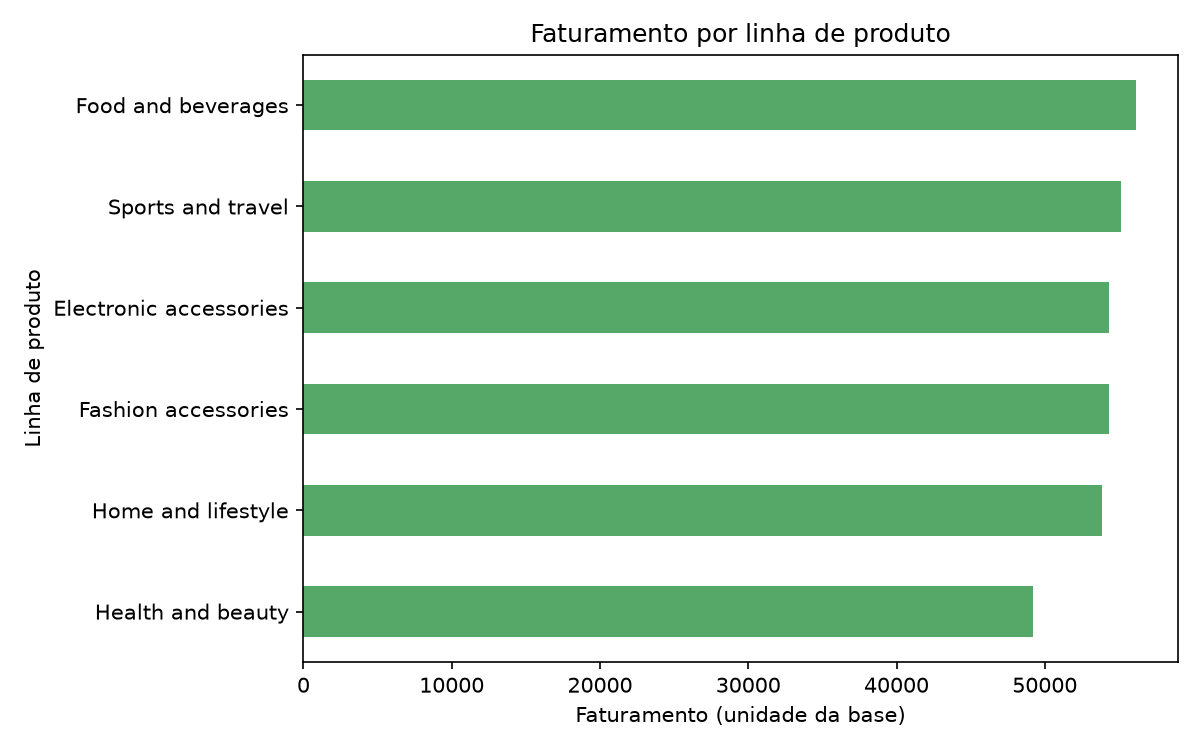

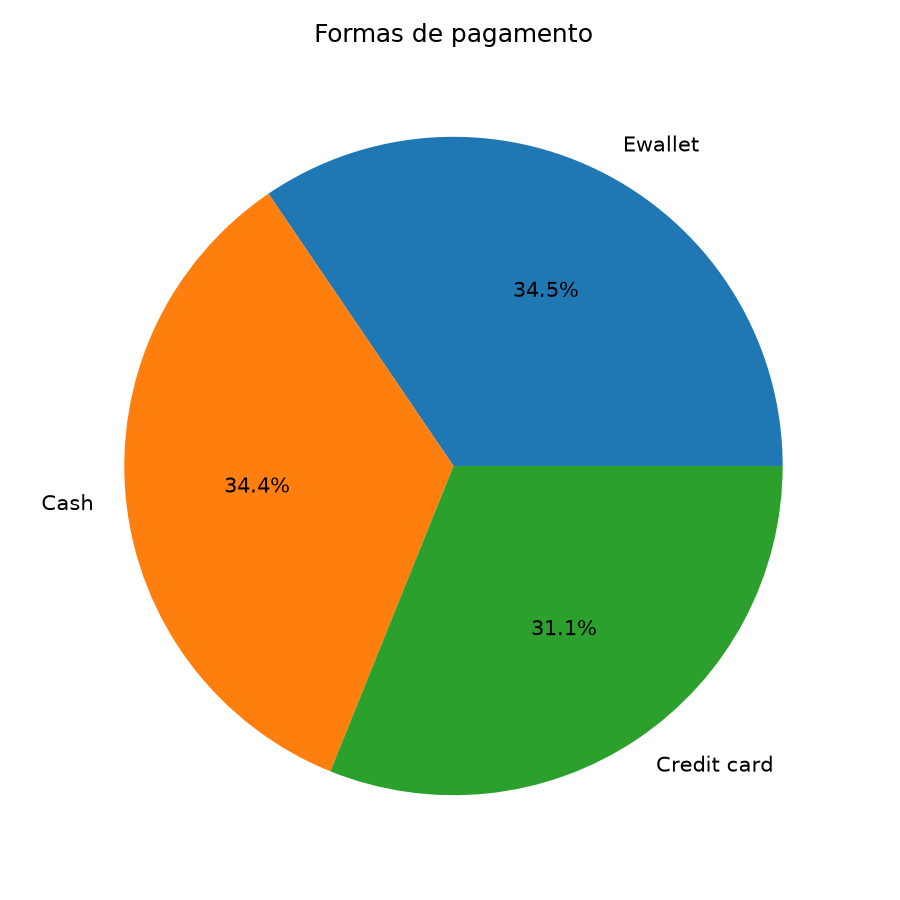

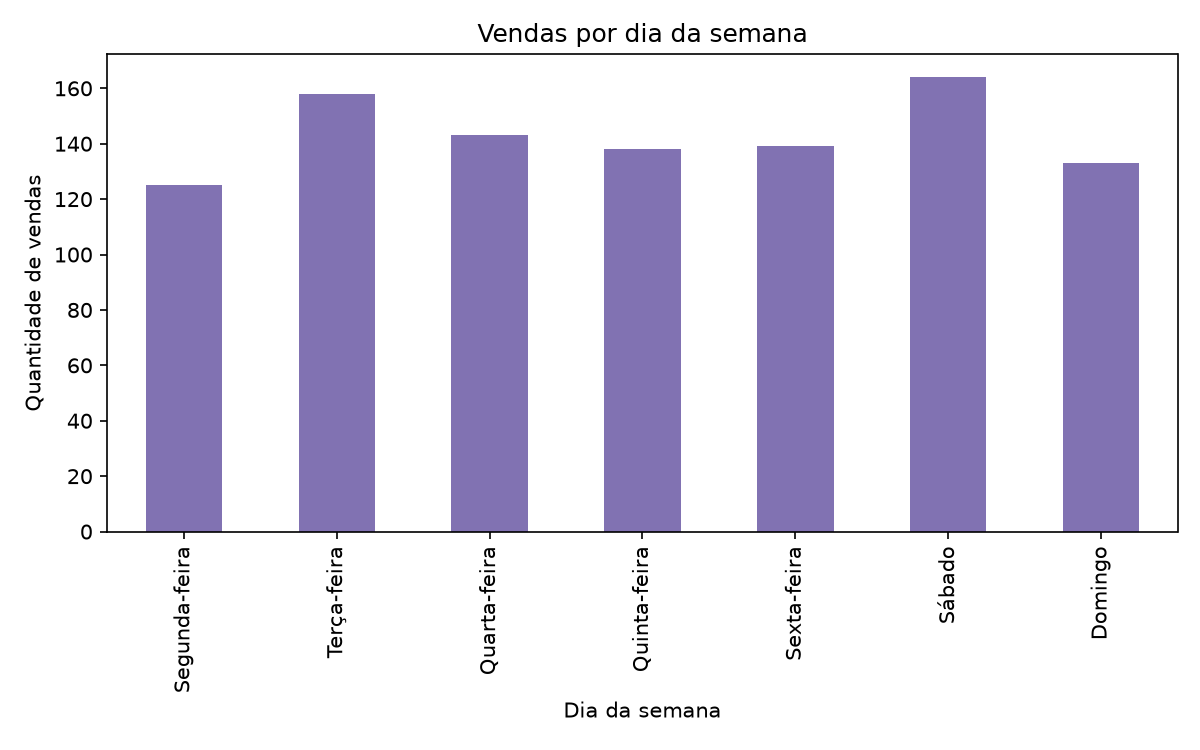

## Hipóteses exploratórias

**H1:** A filial com mais vendas também tem o maior faturamento. Não confirmada.

Comparei Alex, que teve mais vendas, com Giza, que teve o maior faturamento.

**H2:** A linha com maior faturamento também tem a melhor avaliação. Confirmada.

A linha com maior faturamento foi Food and beverages. A melhor avaliação média foi: Food and beverages (nota média 7,11)

Essas conclusões valem para o período da base e não demonstram causa e efeito.